In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Load all cleaned dataframes
df1 = pd.read_excel("Century 21 Cleaned.xlsx")
df2 = pd.read_excel("Tecnocasa Cleaned.xlsx")
df3 = pd.read_excel("Darcom Cleaned.xlsx")
df4 = pd.read_excel("Leaders Immo Cleaned.xlsx")
df5 = pd.read_excel("Tayara BenArous Clean.xlsx")
df6 = pd.read_excel("Tayara Tunis Clean.xlsx")
df7 = pd.read_excel("Tayara Ariana Clean.xlsx")
df8 = pd.read_excel("Tayara Manouba Clean.xlsx")


# Concatenate all
df = pd.concat([df1, df2, df3, df4, df5, df6, df7, df8], ignore_index=True)

df.to_excel("Full Combined Cleaned Data.xlsx", index=False)

print(df.shape)
print(df.head())


(1604, 7)
   Price (TND)     Category  Rooms  Area (m²) Governorate  \
0       470000  Appartement      3      150.0       Tunis   
1       720000  Appartement      3      200.0       Tunis   
2      1200000        Villa      6      480.0       Tunis   
3       560000  Appartement      3      193.0      Ariana   
4       810000  Appartement      3      228.0       Tunis   

                  Area  Source  
0  Jardins De Carthage  Agency  
1  Jardins De Carthage  Agency  
2            El Menzah  Agency  
3               Ennasr  Agency  
4  Jardins De Carthage  Agency  


In [3]:
df.dtypes


Price (TND)      int64
Category        object
Rooms            int64
Area (m²)      float64
Governorate     object
Area            object
Source          object
dtype: object

In [4]:
print(df.isnull().sum())
df.dropna(subset=['Category'], inplace=True)

Price (TND)    0
Category       1
Rooms          0
Area (m²)      0
Governorate    0
Area           0
Source         0
dtype: int64


In [5]:
print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
df.reset_index(inplace=True)
df['row_id'] = df.index


Duplicate rows: 60


In [6]:
df.shape

(1543, 9)

In [7]:
df.head()

,index,Price (TND),Category,Rooms,Area (m²),Governorate,Area,Source,row_id
0,0,470000,Appartement,3,150.0,Tunis,Jardins De Carthage,Agency,0
1,1,720000,Appartement,3,200.0,Tunis,Jardins De Carthage,Agency,1
2,2,1200000,Villa,6,480.0,Tunis,El Menzah,Agency,2
3,3,560000,Appartement,3,193.0,Ariana,Ennasr,Agency,3
4,4,810000,Appartement,3,228.0,Tunis,Jardins De Carthage,Agency,4


In [8]:
df.describe()


,index,Price (TND),Rooms,Area (m²),row_id
count,1543.000000,1.543000e+03,1543.000000,1543.000000,1543.000000
mean,789.785483,2.363133e+06,3.001944,298.657984,771.000000
std,466.482669,4.630592e+07,8.825260,4721.403186,445.570047
min,0.000000,0.000000e+00,1.000000,0.000000,0.000000
25%,386.500000,2.500000e+05,2.000000,95.500000,385.500000
50%,773.000000,3.750000e+05,3.000000,130.000000,771.000000
75%,1201.500000,6.800000e+05,3.000000,200.000000,1156.500000
max,1603.000000,1.350000e+09,335.000000,185538.000000,1542.000000


c:\Users\louay\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


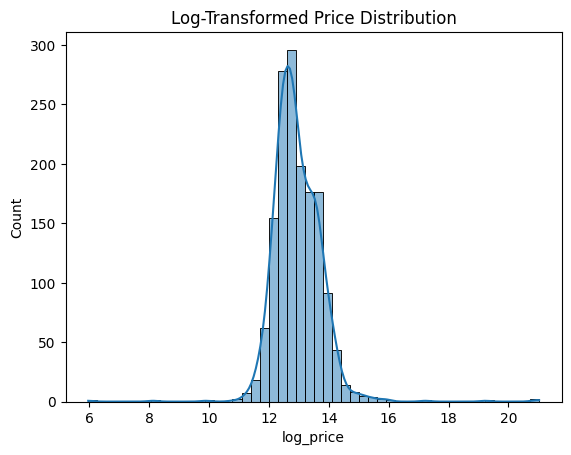

In [9]:
df['log_price'] = np.log(df['Price (TND)'])
sns.histplot(df['log_price'], bins=50, kde=True)
plt.title("Log-Transformed Price Distribution")
plt.show()

In [10]:
df.describe()

c:\Users\louay\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,index,Price (TND),Rooms,Area (m²),row_id,log_price
count,1543.000000,1.543000e+03,1543.000000,1543.000000,1543.000000,1543.000000
mean,789.785483,2.363133e+06,3.001944,298.657984,771.000000,-inf
std,466.482669,4.630592e+07,8.825260,4721.403186,445.570047,NaN
min,0.000000,0.000000e+00,1.000000,0.000000,0.000000,-inf
25%,386.500000,2.500000e+05,2.000000,95.500000,385.500000,12.429216
50%,773.000000,3.750000e+05,3.000000,130.000000,771.000000,12.834681
75%,1201.500000,6.800000e+05,3.000000,200.000000,1156.500000,13.429848
max,1603.000000,1.350000e+09,335.000000,185538.000000,1542.000000,21.023370


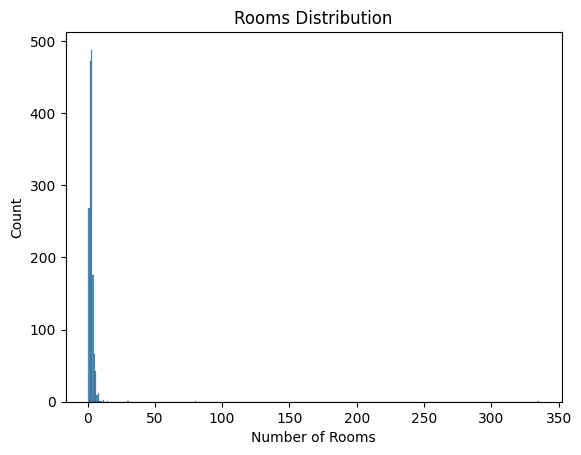

In [11]:
sns.histplot(df['Rooms'], bins=range(1, df['Rooms'].max()+2), discrete=True)
plt.title("Rooms Distribution")
plt.xlabel("Number of Rooms")
plt.ylabel("Count")
plt.show()


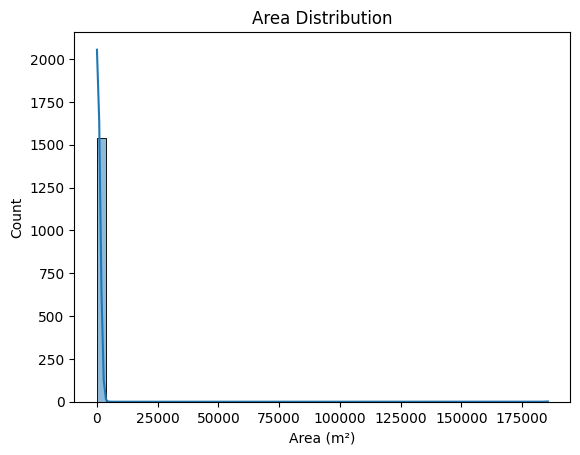

In [12]:
sns.histplot(df['Area (m²)'], bins=50, kde=True)
plt.title("Area Distribution")
plt.xlabel("Area (m²)")
plt.ylabel("Count")
plt.show()


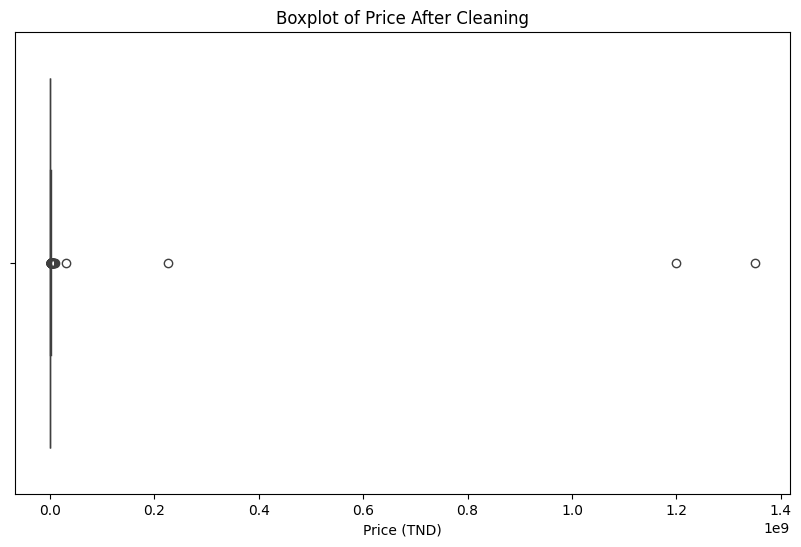

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Price (TND)'])
plt.title("Boxplot of Price After Cleaning")
plt.show()


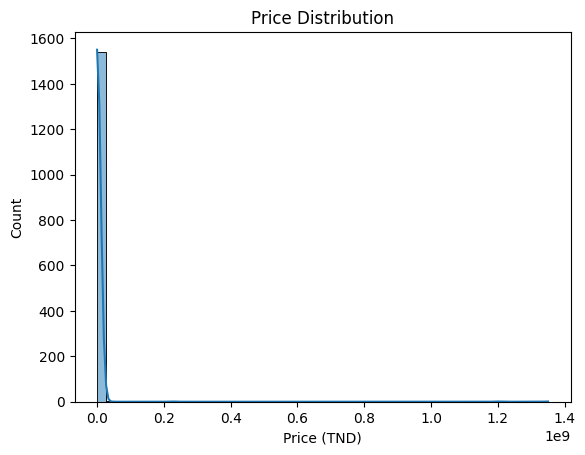

In [14]:
# Histogram for price
sns.histplot(df['Price (TND)'], bins=50, kde=True)
plt.title("Price Distribution")
plt.show()

c:\Users\louay\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


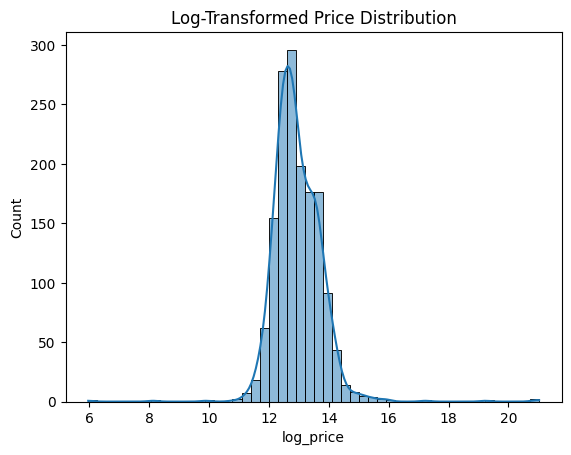

In [15]:
df['log_price'] = np.log(df['Price (TND)'])
sns.histplot(df['log_price'], bins=50, kde=True)
plt.title("Log-Transformed Price Distribution")
plt.show()

C:\Users\louay\AppData\Local\Temp\ipykernel_5596\3485053253.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Governorate', y='Price (TND)', estimator='mean', ci=None, palette='viridis')
C:\Users\louay\AppData\Local\Temp\ipykernel_5596\3485053253.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Governorate', y='Price (TND)', estimator='mean', ci=None, palette='viridis')


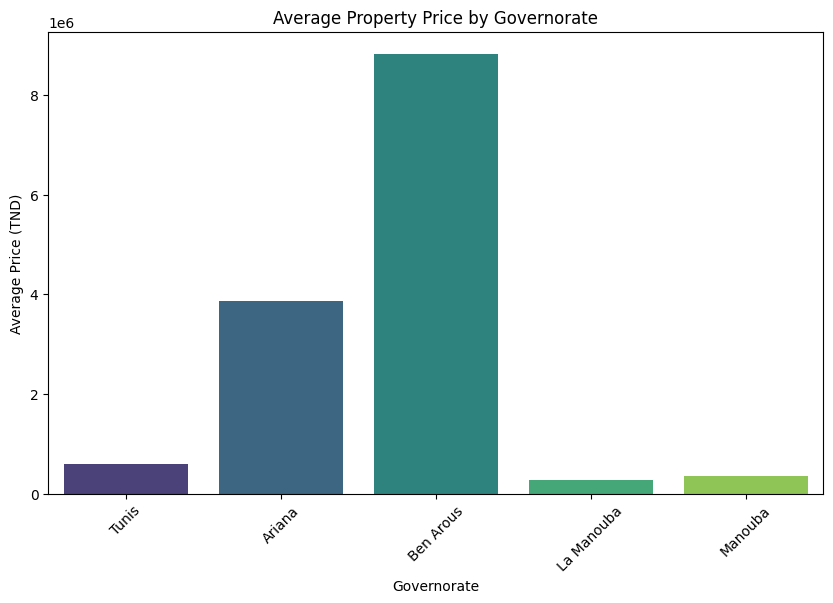

In [16]:
#Goal: Regional comparison.

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Governorate', y='Price (TND)', estimator='mean', ci=None, palette='viridis')
plt.title('Average Property Price by Governorate')
plt.ylabel('Average Price (TND)')
plt.xlabel('Governorate')
plt.xticks(rotation=45)
plt.show()


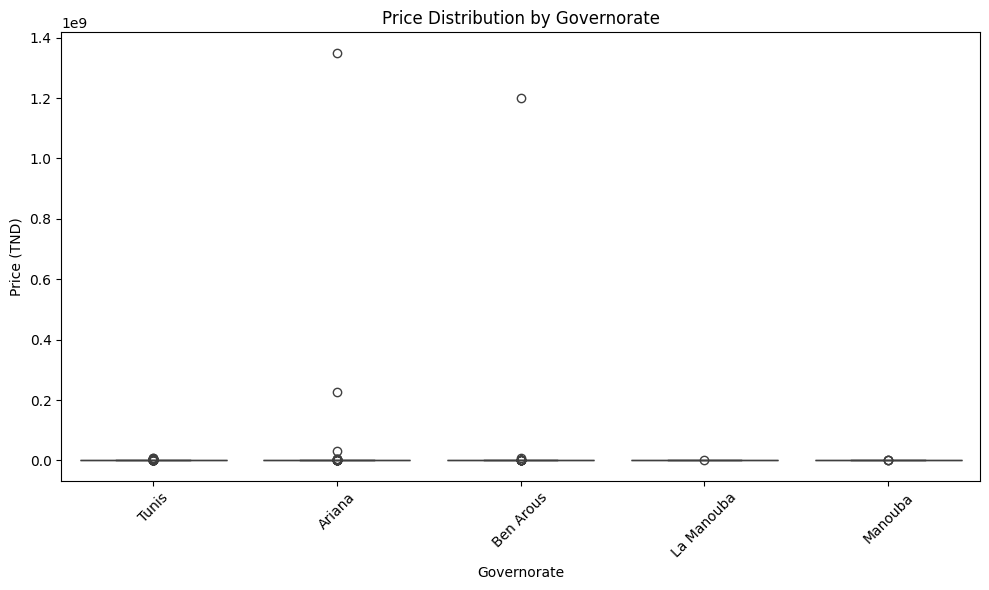

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Governorate', y='Price (TND)')
plt.title('Price Distribution by Governorate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


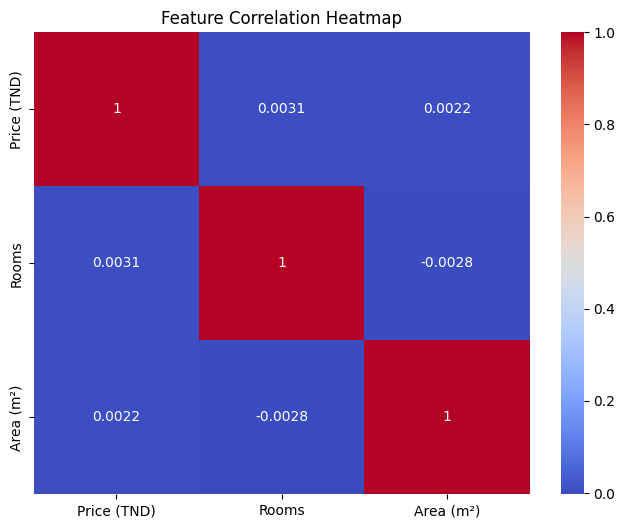

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Price (TND)', 'Rooms', 'Area (m²)']].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


Text(0.5, 1.0, 'Price Comparison: Agencies vs Consumers')

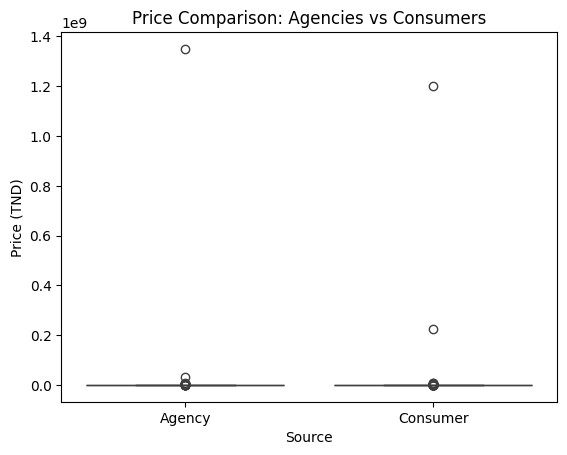

In [19]:
sns.boxplot(data=df, x='Source', y='Price (TND)')
plt.title('Price Comparison: Agencies vs Consumers')


In [20]:
df.shape

(1543, 10)

In [21]:
df["Area"].unique()

array(['Jardins De Carthage', 'El Menzah', 'Ennasr', 'Montplaisir',
       'Beb El Khadhra', 'Aouina', 'Les Berges Du Lac', 'Gammarth',
       'Ain Zaghouan', 'Chotrana', 'La Soukra', 'Carthage',
       'Centre Urbain Nord', 'Ettahrir', 'El Manar', 'Ariana', 'Bou Mhel',
       'Bhar Lazreg', 'Cité Olympique', 'La Marsa', 'Borj Louzir',
       'Rades', 'Raoued', 'Cité El Khadhra', 'Mornag', 'Medina Jedida',
       'Le Bardo', 'Riadh Landalous', 'Ghazela', 'Lafayette',
       'Mutuelle Ville', 'Megrine', 'El Mourouj', 'Le Kram',
       'La Goulette', 'Nour Jaafer', 'La Manouba', 'Ezzahra', 'Mnihla',
       'Les Jardins De Carthage', 'El Kram', 'Ain Zaghouen',
       'El Omrane Superieur', 'Ben Arous', 'El Mohammedia', 'Fouchana',
       'Hammam-Lif', 'Hammam Chott', 'Borj Cedria', 'Tunis', 'El Ouardia',
       'Centre Ville', 'Sidi Hassine', 'Montfleury', 'Beb Mnara',
       'El Agba', 'Ezzouhour', 'El Kabbaria', 'Beb Jdid', 'Beb Saadoun',
       'Dar Fadhal', 'Borj Baccouche', 'Sidi Tha

In [22]:
df[df['Rooms'] == 1].sort_values(by='Price (TND)', ascending=False).head(10)

,index,Price (TND),Category,Rooms,Area (m²),Governorate,Area,Source,row_id,log_price
688,689,30386716,Appartement,1,99.0,Ariana,Ghazela,Agency,688,17.229516
984,1000,5000000,Maison,1,1830.0,Tunis,Montplaisir,Consumer,984,15.424948
740,741,3780000,Appartement,1,638.0,Ariana,Ennasr,Agency,740,15.145235
929,939,3500000,Maison,1,400.0,Tunis,Les Berges Du Lac,Consumer,929,15.068274
711,712,1450000,Maison,1,329.0,Tunis,Ettahrir,Agency,711,14.187074
1308,1362,950000,Villa,1,417.0,Ariana,Ariana,Consumer,1308,13.764217
1313,1367,950000,Villa,1,417.0,Ariana,Borj Baccouche,Consumer,1313,13.764217
746,748,896100,Villa,1,340.0,Ariana,La Soukra,Agency,746,13.705807
702,703,867350,Appartement,1,157.7,Tunis,Les Berges Du Lac,Agency,702,13.673198
703,704,866800,Villa,1,157.6,Tunis,Les Berges Du Lac,Agency,703,13.672564


In [23]:
# Create new features
df["price_per_m2"] = df["Price (TND)"] / df["Area (m²)"]
df["rooms_per_m2"] = df["Rooms"] / df["Area (m²)"]
df["room_area"] = df["Area (m²)"] / df["Rooms"]

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)





df.head(10)

,index,Price (TND),Category,Rooms,Area (m²),Governorate,Area,Source,row_id,log_price,price_per_m2,rooms_per_m2,room_area
0,0,470000,Appartement,3,150.0,Tunis,Jardins De Carthage,Agency,0,13.060488,3133.333333,0.020000,50.000000
1,1,720000,Appartement,3,200.0,Tunis,Jardins De Carthage,Agency,1,13.487006,3600.000000,0.015000,66.666667
2,2,1200000,Villa,6,480.0,Tunis,El Menzah,Agency,2,13.997832,2500.000000,0.012500,80.000000
3,3,560000,Appartement,3,193.0,Ariana,Ennasr,Agency,3,13.235692,2901.554404,0.015544,64.333333
4,4,810000,Appartement,3,228.0,Tunis,Jardins De Carthage,Agency,4,13.604790,3552.631579,0.013158,76.000000
5,5,120000,Appartement,2,65.0,Tunis,Montplaisir,Agency,5,11.695247,1846.153846,0.030769,32.500000
6,6,620000,Appartement,4,230.0,Ariana,Ennasr,Agency,6,13.337475,2695.652174,0.017391,57.500000
7,7,530000,Appartement,3,144.0,Ariana,Ennasr,Agency,7,13.180632,3680.555556,0.020833,48.000000
8,8,750000,Appartement,3,180.0,Tunis,Jardins De Carthage,Agency,8,13.527828,4166.666667,0.016667,60.000000
9,9,550000,Appartement,4,295.0,Tunis,Beb El Khadhra,Agency,9,13.217674,1864.406780,0.013559,73.750000


In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,  cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
import joblib


## Drop non-numeric or redundant columns
drop_cols = ['Price (TND)', 'Area', 'Source', 'index', 'row_id']
X = df.drop(columns=drop_cols + ['log_price'])
y = df['log_price']


original_shape = X.shape
print("Shape before One-Hot Encoding:", original_shape)

# One-hot encode categorical variables
X = pd.get_dummies(X, columns=['Category', 'Governorate'], drop_first=True)

encoded_shape = X.shape
print("Shape after One-Hot Encoding:", encoded_shape)
# Sauvegarder la liste des colonnes après encodage
joblib.dump(X.columns.tolist(), "columns.joblib")


Shape before One-Hot Encoding: (1540, 7)
Shape after One-Hot Encoding: (1540, 12)


['columns.joblib']

In [32]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------
#  RANDOM FOREST
# -------------------------------
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42
)
rf.fit(X_train, y_train)

y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

print(" Random Forest Results:")
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred_rf)))
print("Test MAE:", np.sqrt(mean_absolute_error(y_test, y_test_pred_rf)))
print("Test R²:", r2_score(y_test, y_test_pred_rf))
print("=" * 50)

# Inverse transform to get actual prices
y_test_actual = np.exp(y_test)
y_test_pred_actual = np.exp(y_test_pred_rf)  # or y_test_pred_xgb

# Compute evaluation metrics in TND
from sklearn.metrics import mean_absolute_error

rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_test_pred_actual))
mae_actual = mean_absolute_error(y_test_actual, y_test_pred_actual)


print("Test RMSE (TND):", rmse_actual)
print("Test MAE (TND):", mae_actual)



# Cross-validation for RF
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rf_scores = cross_val_score(rf, X, y, cv=cv, scoring='r2')
print("CV R² RF (mean):", np.mean(cv_rf_scores))
print("=" * 50)

 Random Forest Results:
Test RMSE: 0.19449928461419164
Test MAE: 0.3627908667584519
Test R²: 0.924425477185399
Test RMSE (TND): 356763.75719752227
Test MAE (TND): 102449.5376637897
CV R² RF (mean): 0.7558306908004908


In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define parameter grid
param_grid_rf = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# Initialize model
rf = RandomForestRegressor(random_state=42)

# Grid search
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

# Best model
best_rf = grid_rf.best_estimator_
print("Best RF Params:", grid_rf.best_params_)

# Predictions
y_pred_rf = best_rf.predict(X_test)

# Metrics in log scale
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_log = mean_absolute_error(y_test, y_pred_rf)
r2_log = r2_score(y_test, y_pred_rf)

# Back-transform predictions
y_test_exp = np.exp(y_test)
y_pred_exp = np.exp(y_pred_rf)

rmse_tnd = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
mae_tnd = mean_absolute_error(y_test_exp, y_pred_exp)


# Print results
print("\n Tuned Random Forest Performance:")
print(f"RMSE (log): {rmse_log}")
print(f"MAE (log): {mae_log}")
print(f"R² (log): {r2_log}")
print(f"RMSE (TND): {rmse_tnd}")
print(f"MAE (TND): {mae_tnd}")



Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best RF Params: {'bootstrap': False, 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

 Tuned Random Forest Performance:
RMSE (log): 0.16494001482101533
MAE (log): 0.1016453940347838
R² (log): 0.9456510127708866
RMSE (TND): 338855.87944643904
MAE (TND): 88191.17100792148


In [34]:
#  XGBOOST
# -------------------------------
xgb = XGBRegressor(
    n_estimators=200,
    max_depth=4,  # smaller depth
    learning_rate=0.05,  # slower learning
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1,      # stronger L1
    reg_lambda=2,     # stronger L2
    gamma=1,          # min loss reduction to split
    random_state=42,
    verbosity=0
)
xgb.fit(X_train, y_train)

y_train_pred_xgb = xgb.predict(X_train)
y_test_pred_xgb = xgb.predict(X_test)

print(" XGBoost Results:")
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred_xgb)))
print("Test MAE:", np.sqrt(mean_absolute_error(y_test, y_test_pred_xgb)))
print("Test R²:", r2_score(y_test, y_test_pred_xgb))
print("=" * 50)


y_test_actual = np.exp(y_test)
y_test_pred_actual = np.exp(y_test_pred_xgb)


rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_test_pred_actual))
mae_actual = mean_absolute_error(y_test_actual, y_test_pred_actual)

print("Test RMSE (TND):", rmse_actual)
print("Test MAE (TND):", mae_actual)



# Cross-validation for XGB
cv_xgb_scores = cross_val_score(xgb, X, y, cv=cv, scoring='r2')
print("CV R² XGB (mean):", np.mean(cv_xgb_scores))

 XGBoost Results:
Test RMSE: 0.12610390974705216
Test MAE: 0.2770454561792636
Test R²: 0.9682315152787524
Test RMSE (TND): 254928.88083528707
Test MAE (TND): 66934.04900568182
CV R² XGB (mean): 0.8951364474259579


In [35]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

# Define the model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Define the parameter grid
param_dist = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'gamma': [0, 1, 3, 5],
    'reg_alpha': [0, 1, 5, 10],
    'reg_lambda': [1, 2, 5, 10]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,               # number of random combinations
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit to data
random_search.fit(X_train, y_train)

# Best model
best_model = random_search.best_estimator_
print("Best Params:", random_search.best_params_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params: {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 1.0}


In [36]:
y_pred = best_model.predict(X_test)

y_pred_tnd = np.exp(y_pred)
y_test_tnd = np.exp(y_test)

# Evaluate
print("RMSE (log):", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE (log):", mean_absolute_error(y_test, y_pred))
print("R² (log):", r2_score(y_test, y_pred))

print("RMSE (TND):", np.sqrt(mean_squared_error(y_test_tnd, y_pred_tnd)))
print("MAE (TND):", mean_absolute_error(y_test_tnd, y_pred_tnd))


RMSE (log): 0.1077252427107083
MAE (log): 0.06572594331049135
R² (log): 0.9768167478071652
RMSE (TND): 207982.03960190836
MAE (TND): 53958.22869318181


In [ ]:
# À la fin de votre notebook, ajoutez:
import joblib


# Supposons que vous avez un modèle nommé 'model'
joblib.dump(best_model, 'immobilier_model.pkl')


['immobilier_model.pkl']